In [14]:
import pandas as pd

df = pd.read_csv('c:/data/insta/insta_test.csv')
df.head()

,user_id,app_name,age,gender,country,income_level,employment_status,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,...,dms_sent_per_week,dms_received_per_week,ads_viewed_per_day,ads_clicked_per_day,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count
0,1,Instagram,51,Female,India,High,Retired,7.2,7.7,3,...,12,12,4,1,2,1,1,2,374,647
1,2,Instagram,64,Female,United Kingdom,Middle,Full-time employed,10.9,8.6,1,...,18,10,11,1,31,19,16,19,2585,3511
2,3,Instagram,41,Female,Canada,Middle,Student,5.0,6.7,4,...,12,13,4,0,3,1,1,1,3414,6761
3,4,Instagram,27,Non-binary,South Korea,Middle,Unemployed,10.6,6.5,18,...,31,32,33,3,108,64,52,64,617,1193
4,5,Instagram,55,Male,India,Upper-middle,Full-time employed,7.7,6.8,19,...,29,37,20,5,78,55,22,55,1157,1072


In [3]:
df.columns

Index(['user_id', 'app_name', 'age', 'gender', 'country', 'income_level',
       'employment_status', 'exercise_hours_per_week', 'sleep_hours_per_night',
       'perceived_stress_score', 'self_reported_happiness',
       'daily_steps_count', 'weekly_work_hours',
       'daily_active_minutes_instagram', 'sessions_per_day',
       'posts_created_per_week', 'reels_watched_per_day',
       'stories_viewed_per_day', 'likes_given_per_day',
       'comments_written_per_day', 'dms_sent_per_week',
       'dms_received_per_week', 'ads_viewed_per_day', 'ads_clicked_per_day',
       'time_on_feed_per_day', 'time_on_explore_per_day',
       'time_on_messages_per_day', 'time_on_reels_per_day', 'followers_count',
       'following_count'],
      dtype='object')

In [4]:
#더미변수
income_level_dummy = pd.get_dummies(df['income_level'], prefix='income')
employment_status_dummy = pd.get_dummies(df['employment_status'],prefix='emp')
df_dummy = pd.concat([df, income_level_dummy, employment_status_dummy], axis=1)
df = df_dummy.drop(columns=['user_id','app_name','gender','country','income_level', 'employment_status'])

In [5]:
X = df.drop('perceived_stress_score', axis=1)
y = df['perceived_stress_score']
X.columns

Index(['age', 'exercise_hours_per_week', 'sleep_hours_per_night',
       'self_reported_happiness', 'daily_steps_count', 'weekly_work_hours',
       'daily_active_minutes_instagram', 'sessions_per_day',
       'posts_created_per_week', 'reels_watched_per_day',
       'stories_viewed_per_day', 'likes_given_per_day',
       'comments_written_per_day', 'dms_sent_per_week',
       'dms_received_per_week', 'ads_viewed_per_day', 'ads_clicked_per_day',
       'time_on_feed_per_day', 'time_on_explore_per_day',
       'time_on_messages_per_day', 'time_on_reels_per_day', 'followers_count',
       'following_count', 'income_High', 'income_Low', 'income_Lower-middle',
       'income_Middle', 'income_Upper-middle', 'emp_Freelancer',
       'emp_Full-time employed', 'emp_Retired', 'emp_Student',
       'emp_Unemployed'],
      dtype='object')

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
#스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
import numpy as np
df.corr()

,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,daily_steps_count,weekly_work_hours,daily_active_minutes_instagram,sessions_per_day,posts_created_per_week,...,income_High,income_Low,income_Lower-middle,income_Middle,income_Upper-middle,emp_Freelancer,emp_Full-time employed,emp_Retired,emp_Student,emp_Unemployed
age,1.000000,0.425209,0.442666,-2.100042e-01,-0.018243,0.260582,-0.132763,-0.304505,-0.045372,-0.586258,...,0.057495,-0.013606,-0.119464,0.033193,6.587917e-02,0.055872,0.265285,-0.364635,0.107673,-0.175895
exercise_hours_per_week,0.425209,1.000000,0.102059,-3.919659e-02,-0.282243,-0.186118,0.057609,0.012351,0.029165,-0.266940,...,-0.015799,-0.357590,-0.264925,0.567292,-1.215600e-01,0.137009,0.020409,-0.069033,-0.199271,0.229707
sleep_hours_per_night,0.442666,0.102059,1.000000,-1.991469e-01,0.219799,0.214894,-0.377931,-0.356310,-0.303210,-0.447238,...,0.187396,-0.138058,0.043190,-0.156544,1.776962e-01,0.143849,0.072753,-0.106536,-0.024750,-0.122888
perceived_stress_score,-0.210004,-0.039197,-0.199147,1.000000e+00,-0.179173,-0.066643,0.324600,0.881771,0.740235,0.581156,...,-0.291888,0.087971,0.219758,-0.051722,-3.365523e-17,-0.079080,0.047521,0.040364,-0.082610,0.045574
self_reported_happiness,-0.018243,-0.282243,0.219799,-1.791729e-01,1.000000,0.113772,-0.148624,-0.530462,-0.331255,-0.158233,...,0.328911,-0.028201,0.053052,-0.142830,-1.787227e-01,0.414485,-0.150816,-0.102222,0.176373,-0.281383
daily_steps_count,0.260582,-0.186118,0.214894,-6.664348e-02,0.113772,1.000000,-0.001529,-0.075357,0.041049,-0.237627,...,0.034777,0.422709,-0.099144,-0.362475,1.806576e-01,-0.215966,-0.049295,0.399513,0.041433,-0.458895
weekly_work_hours,-0.132763,0.057609,-0.377931,3.246003e-01,-0.148624,-0.001529,1.000000,0.352850,0.228068,0.334135,...,0.368976,0.104422,-0.121119,-0.238494,2.107398e-02,0.016905,-0.244650,0.253350,-0.018870,0.102979
daily_active_minutes_instagram,-0.304505,0.012351,-0.356310,8.817710e-01,-0.530462,-0.075357,0.352850,1.000000,0.796740,0.688026,...,-0.331824,0.136153,0.157855,-0.016233,1.047316e-02,-0.213776,-0.036053,0.177980,-0.069248,0.138466
sessions_per_day,-0.045372,0.029165,-0.303210,7.402355e-01,-0.331255,0.041049,0.228068,0.796740,1.000000,0.483141,...,-0.262988,-0.028635,0.077519,0.084421,8.880750e-02,-0.204643,0.140288,-0.006569,-0.030655,-0.002670
posts_created_per_week,-0.586258,-0.266940,-0.447238,5.811562e-01,-0.158233,-0.237627,0.334135,0.688026,0.483141,1.000000,...,-0.049917,0.147656,0.040650,-0.022324,-1.592796e-01,-0.039820,-0.055220,0.230348,-0.149751,-0.027538


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
font_name = font_manager.FontProperties(fname='c:/Windows/Fonts/malgun.ttf').get_name()
rc('font',family=font_name)

C:\python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


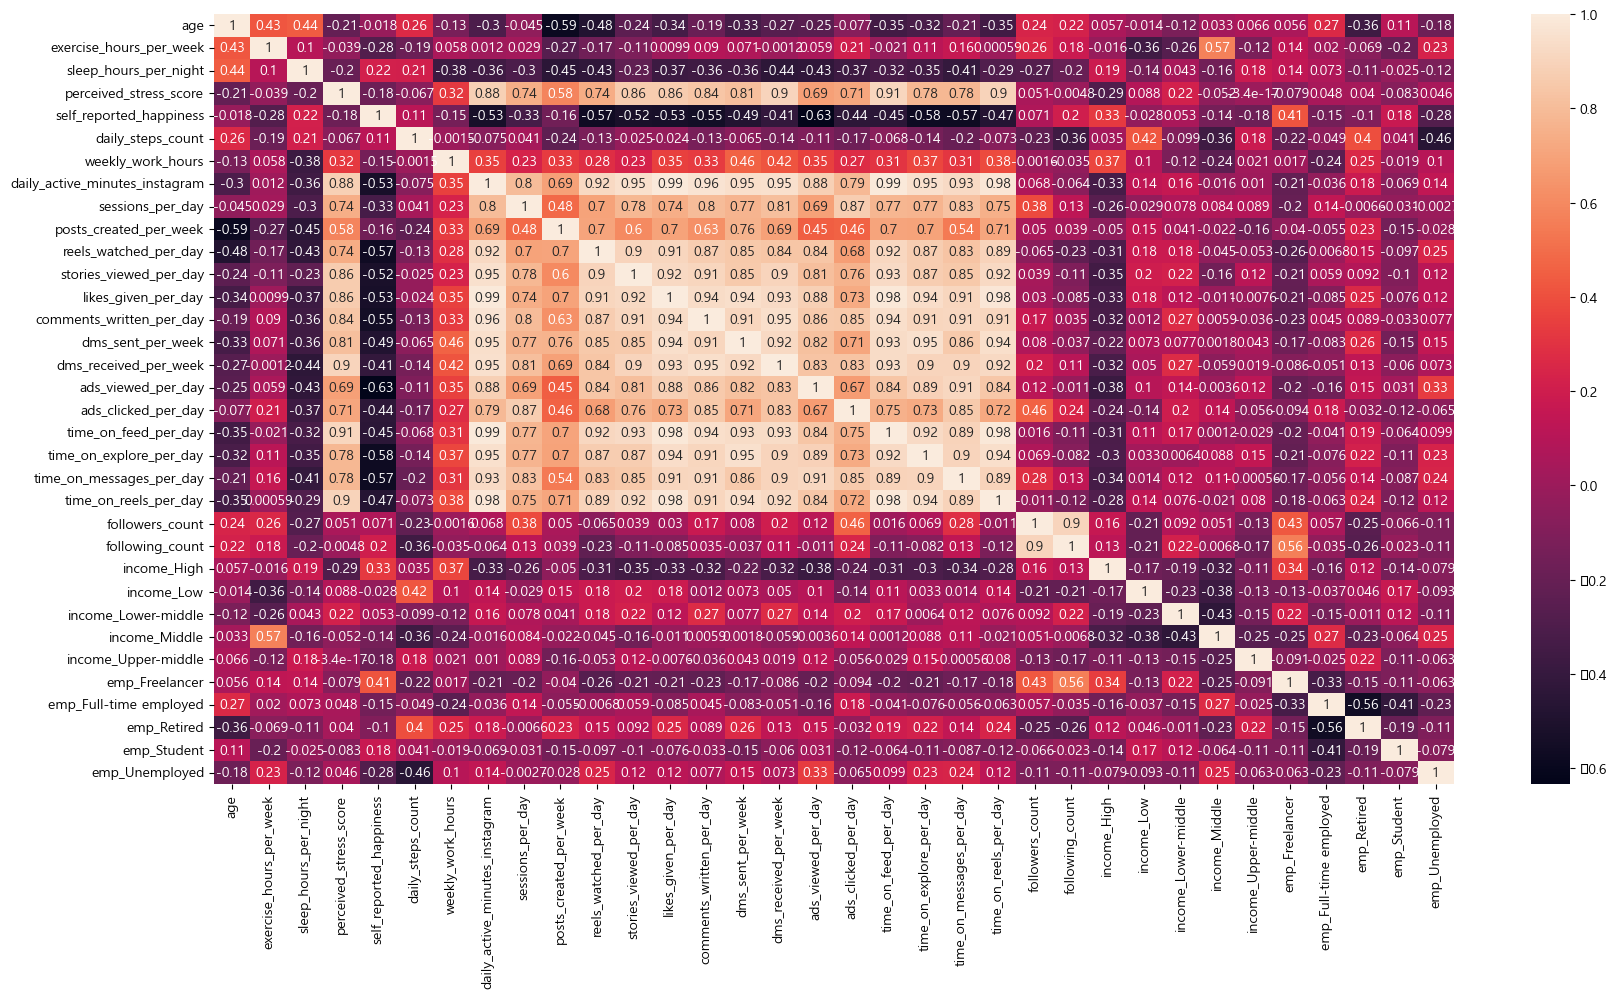

In [10]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

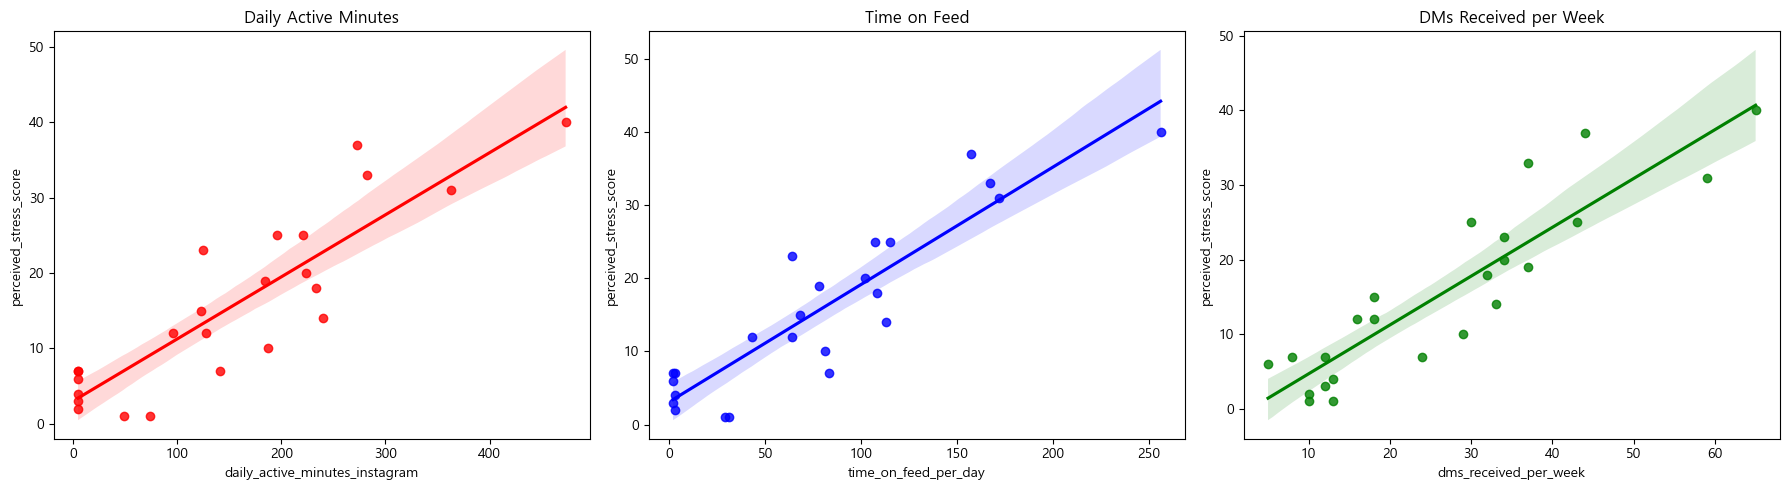

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(18, 5))   # 1행 3열 Figure 생성

sns.regplot(
    x='daily_active_minutes_instagram',
    y='perceived_stress_score',
    data=df,
    color='red',
    ax=ax[0]
)
ax[0].set_title('Daily Active Minutes')

sns.regplot(
    x='time_on_feed_per_day',
    y='perceived_stress_score',
    data=df,
    color='blue',
    ax=ax[1]
)
ax[1].set_title('Time on Feed')

sns.regplot(
    x='dms_received_per_week',
    y='perceived_stress_score',
    data=df,
    color='green',
    ax=ax[2]
)
ax[2].set_title('DMs Received per Week')

plt.tight_layout()   # 그래프 겹침 방지
plt.show()

In [12]:
import statsmodels.api as sm

model = sm.OLS(y_train, X_train)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                   OLS Regression Results                                  
===========================================================================================
Dep. Variable:     perceived_stress_score   R-squared (uncentered):                   0.368
Model:                                OLS   Adj. R-squared (uncentered):            -11.017
Method:                     Least Squares   F-statistic:                            0.03228
Date:                    Fri, 06 Feb 2026   Prob (F-statistic):                        1.00
Time:                            09:57:43   Log-Likelihood:                         -78.413
No. Observations:                      19   AIC:                                      192.8
Df Residuals:                           1   BIC:                                      209.8
Df Model:                              18                                                  
Covariance Type:                nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.8256     31.653      0.026      0.983    -401.365     403.016
x2            -0.2971     30.320     -0.010      0.994    -385.552     384.958
x3             0.3548     30.967      0.011      0.993    -393.118     393.827
x4             6.1025     26.019      0.235      0.853    -324.503     336.708
x5            -1.2070     25.909     -0.047      0.970    -330.408     327.994
x6             0.0982     29.438      0.003      0.998    -373.950     374.147
x7             1.8927      5.784      0.327      0.799     -71.601      75.386
x8            -0.7061     26.773     -0.026      0.983    -340.891     339.479
x9            -3.0689     31.676     -0.097      0.939    -405.545     399.407
x10           -0.9579     16.721     -0.057      0.964    -213.418     211.502
x11            1.9455     25.969      0.075      0.952    -328.017     331.908
x12            2.8619     16.055      0.178      0.888    -201.134     206.858
x13            1.1135     16.036      0.069      0.956    -202.643     204.870
x14           -1.0959     42.944     -0.026      0.984    -546.750     544.558
x15            2.3275     17.815      0.131      0.917    -224.037     228.692
x16            1.0027     27.974      0.036      0.977    -354.446     356.451
x17           -0.6647     24.021     -0.028      0.982    -305.882     304.552
x18            3.8353     14.328      0.268      0.833    -178.216     185.886
x19           -0.5488     20.809     -0.026      0.983    -264.951     263.854
x20            1.4670     22.577      0.065      0.959    -285.398     288.332
x21            3.5762     14.519      0.246      0.846    -180.910     188.062
x22           -1.1981     26.366     -0.045      0.971    -336.207     333.811
x23            0.8904     17.752      0.050      0.968    -224.670     226.451
x24           -0.9337     19.003     -0.049      0.969    -242.387     240.519
x25           -0.1413     20.408     -0.007      0.996    -259.446     259.163
x26           -0.5522     19.506     -0.028      0.982    -248.397     247.292
x27            0.3960     18.830      0.021      0.987    -238.859     239.651
x28            1.2871     17.023      0.076      0.952    -215.005     217.579
x29            0.2064     22.189      0.009      0.994    -281.733     282.145
x30            0.8062     12.684      0.064      0.960    -160.356     161.968
x31           -0.0351     30.715     -0.001      0.999    -390.306     390.236
x32           -1.0009     15.686     -0.064      0.959    -200.315     198.313
x33           -0.3837     20.646     -0.019      0.988    -262.718     261.951
==============================================================================
Omnibus:         

In [13]:
X = df[['daily_active_minutes_instagram','time_on_feed_per_day','dms_received_per_week']]
y = df['perceived_stress_score']
print(X.head())
print(y.head())

   daily_active_minutes_instagram  time_on_feed_per_day  dms_received_per_week
0                               5                     2                     12
1                              74                    31                     10
2                               5                     3                     13
3                             233                   108                     32
4                             184                    78                     37
0     3
1     1
2     4
3    18
4    19
Name: perceived_stress_score, dtype: int64


In [ ]:
import statsmodels.api as sm
model = sm.OLS(y, X)
result = model.fit()
result.summary()